In [1]:
# Imports

import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
BASE_DIR = os.path.dirname(os.getcwd())

IMAGE_DIR = os.path.join(BASE_DIR, "data/raw/images")
MASK_DIR = os.path.join(BASE_DIR, "data/raw/masks")

OUTPUT_IMAGE_DIR = os.path.join(BASE_DIR, "data/processed/images")
OUTPUT_MASK_DIR = os.path.join(BASE_DIR, "data/processed/masks")

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)

print(BASE_DIR)
print(IMAGE_DIR)
print(MASK_DIR)
print(OUTPUT_IMAGE_DIR)
print(OUTPUT_MASK_DIR)

# Parameters

IMG_SIZE = 256  # Resize to 256x256

# Helper Functions

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return mask

def normalize_image(img):
    img = img / 255.0
    return img

def resize_image(img, size=256): 
    return cv2.resize(img, (size, size))

def resize_mask(mask, size=256):
    return cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

def preprocess_mask(mask):
    """
    Convert mask to binary (or multi-class if needed)
    """
    mask = mask / 255.0
    mask = np.round(mask)  # ensure 0 or 1
    return mask


# Preprocessing Loop


image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Total images: {len(image_files)}")
print(f"Total masks: {len(mask_files)}")

for img_file, mask_file in tqdm(zip(image_files, mask_files), total=len(image_files)):

    img_path = os.path.join(IMAGE_DIR, img_file)
    mask_path = os.path.join(MASK_DIR, mask_file)

    # Load
    image = load_image(img_path)
    mask = load_mask(mask_path)

    # Resize
    image = resize_image(image, IMG_SIZE)
    mask = resize_mask(mask, IMG_SIZE)

    # Normalize
    image = normalize_image(image)
    mask = preprocess_mask(mask)

    # Save
    np.save(os.path.join(OUTPUT_IMAGE_DIR, img_file.replace(".png", ".npy")), image)
    np.save(os.path.join(OUTPUT_MASK_DIR, mask_file.replace(".png", ".npy")), mask)

print("Preprocessing complete!")

c:\Users\hamad\OneDrive\Desktop\ML - P
c:\Users\hamad\OneDrive\Desktop\ML - P\data/raw/images
c:\Users\hamad\OneDrive\Desktop\ML - P\data/raw/masks
c:\Users\hamad\OneDrive\Desktop\ML - P\data/processed/images
c:\Users\hamad\OneDrive\Desktop\ML - P\data/processed/masks
Total images: 3064
Total masks: 3064


100%|██████████| 3064/3064 [01:47<00:00, 28.63it/s]  

Preprocessing complete!


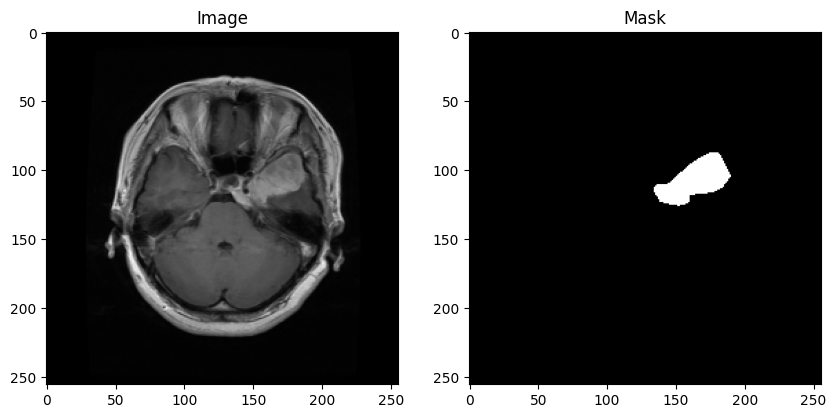

In [18]:
# Visualization Check


sample_idx = 0

sample_image = np.load(os.path.join(OUTPUT_IMAGE_DIR, os.listdir(OUTPUT_IMAGE_DIR)[sample_idx]))
sample_mask = np.load(os.path.join(OUTPUT_MASK_DIR, os.listdir(OUTPUT_MASK_DIR)[sample_idx]))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(sample_image)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(sample_mask, cmap='gray')

plt.show()

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        # ✅ Correct loading for .npy
        image = np.load(img_path)
        mask = np.load(mask_path)

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        # Fix shape
        if len(image.shape) == 3:
            image = image.permute(2, 0, 1)

        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [28]:
from torch.utils.data import DataLoader

dataset = BrainTumorDataset(os.path.join(BASE_DIR, "data/processed/images"), 
                            os.path.join(BASE_DIR, "data/processed/masks"))

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [29]:
for images, masks in loader:
    print(images.shape)  # [B, C, H, W]
    print(masks.shape)
    break

torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])
